In [1]:
import duckdb
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from srm import downscaling_utils

In [3]:
from srm import run_bcsd

# 0. Get data

In [4]:
RUN_PARAMETERS = {
    "gcm": "CESM2-WACCM",
    "train_period_start": 1978,
    "train_period_end": 2014,
    "predict_period_start": 2015,
    "predict_period_end": 2100,
    "var_name": "tas",
}

In [5]:
dict_all = run_bcsd.get_all_data(
    gcm=RUN_PARAMETERS["gcm"], var_name=RUN_PARAMETERS["var_name"], verbose=True
)

Loaded data: 1.17 seconds
Subset time: 0.00 seconds


In [6]:
for key in dict_all:
    print(key)

model_hist
obs
model_scenario


### Subset data to demo region (South Africa)

In [7]:
df = duckdb.sql(
    """install httpfs; load httpfs; install spatial; load spatial; SELECT name, ST_AsText(geom) as geometry FROM ST_Read('https://carbonplan-data.s3.us-west-2.amazonaws.com/countries-50m.json') WHERE NAME = 'South Africa'"""
).df()
df["geometry"] = gpd.GeoSeries.from_wkt(df["geometry"])
south_africa_geom = gpd.GeoDataFrame(df, geometry="geometry")

# Set bounds as a couple of degrees around South Africa
lon_min, lat_min, lon_max, lat_max = south_africa_geom.total_bounds
lon_min = lon_min - 2
lon_max = lon_max + 2
lat_min = lat_min - 2
lat_max = lat_max + 2

In [8]:
dict_all["obs"] = downscaling_utils.subset_space(
    dict_all["obs"], coord_bounds_list=[lat_min - 2, lat_max + 2, lon_min - 2, lon_max + 2]
)

dict_all["model_hist"] = downscaling_utils.subset_space(
    dict_all["model_hist"], coord_bounds_list=[lat_min, lat_max, lon_min, lon_max]
)

dict_all["model_scenario"] = downscaling_utils.subset_space(
    dict_all["model_scenario"], coord_bounds_list=[lat_min, lat_max, lon_min, lon_max]
)

# 1. Preprocess data

In [9]:
rechunk_workflow = True  # flag: whether to rechunk data depending on the step

In [10]:
dict_all = run_bcsd.preprocess_data(
    dict_all,
    train_period_start=RUN_PARAMETERS["train_period_start"],
    train_period_end=RUN_PARAMETERS["train_period_end"],
    predict_period_start=RUN_PARAMETERS["predict_period_start"],
    predict_period_end=RUN_PARAMETERS["predict_period_end"],
    verbose=True,
    rechunk_workflow=rechunk_workflow,
)

Rechunked obs to full space: 5.20 seconds
Interpolated obs to coarse grid: 35.69 seconds


In [11]:
for key in dict_all:
    print(key)

model_hist
obs
model_scenario
obs_coarse


# 2. Bias correct with quantile mapping

In [12]:
dict_all = run_bcsd.bias_correct(
    dict_all=dict_all,
    var_name=RUN_PARAMETERS["var_name"],
    verbose=True,
    rechunk_workflow=rechunk_workflow,
)

100%|██████████| 620/620 [00:01<00:00, 592.85it/s]


Quantile mapped historical: 2.06 seconds


100%|██████████| 620/620 [00:02<00:00, 306.40it/s]


Quantile mapped future: 2.81 seconds


In [13]:
for key in dict_all:
    print(key)

model_hist
obs
model_scenario
obs_coarse
model_hist_debiased
scenario_debiased


# 3. Downscale

In [14]:
dict_all = run_bcsd.spatially_disaggregate(
    dict_all=dict_all, verbose=True, rechunk_workflow=rechunk_workflow
)

Rechunked all to full time: 1.98 seconds
Calculate error map for spatial disaggregation: 5.21 seconds
Downscaled historical: 1.82 seconds
Downscaled future: 4.27 seconds


In [15]:
for key in dict_all:
    print(key)

model_hist
obs
model_scenario
obs_coarse
model_hist_debiased
scenario_debiased
model_hist_debiased_downscaled
scenario_debiased_downscaled


# Look at results at Cape Town, South Africa

In [16]:
cities = gpd.read_file(
    "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_populated_places_simple.zip",
    columns=["name", "sov0name", "geometry"],
)
sa_cities = cities[cities["sov0name"] == "South Africa"]
cape_town_x, cape_town_y = (
    float(sa_cities[sa_cities["name"] == "Cape Town"].geometry.x),
    float(sa_cities[sa_cities["name"] == "Cape Town"].geometry.y),
)

/tmp/ipykernel_980/1595652233.py:7: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  float(sa_cities[sa_cities["name"] == "Cape Town"].geometry.x),
/tmp/ipykernel_980/1595652233.py:8: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  float(sa_cities[sa_cities["name"] == "Cape Town"].geometry.y),


In [17]:
for key in dict_all:
    print(key)
    dict_all[key].compute()

model_hist
obs
model_scenario
obs_coarse
model_hist_debiased
scenario_debiased
model_hist_debiased_downscaled
scenario_debiased_downscaled


In [18]:
dict_all_CT = {}
for key, ds in dict_all.items():
    print(key)
    ds_CT = ds.sel(lat=cape_town_y, lon=cape_town_x, method="nearest").compute()
    dict_all_CT[key] = ds_CT

model_hist
obs
model_scenario
obs_coarse
model_hist_debiased
scenario_debiased
model_hist_debiased_downscaled
scenario_debiased_downscaled


In [19]:
dict_all_CT["model_scenario_debiased"] = dict_all_CT["scenario_debiased"]
dict_all_CT["model_scenario_debiased_downscaled"] = dict_all_CT["scenario_debiased_downscaled"]

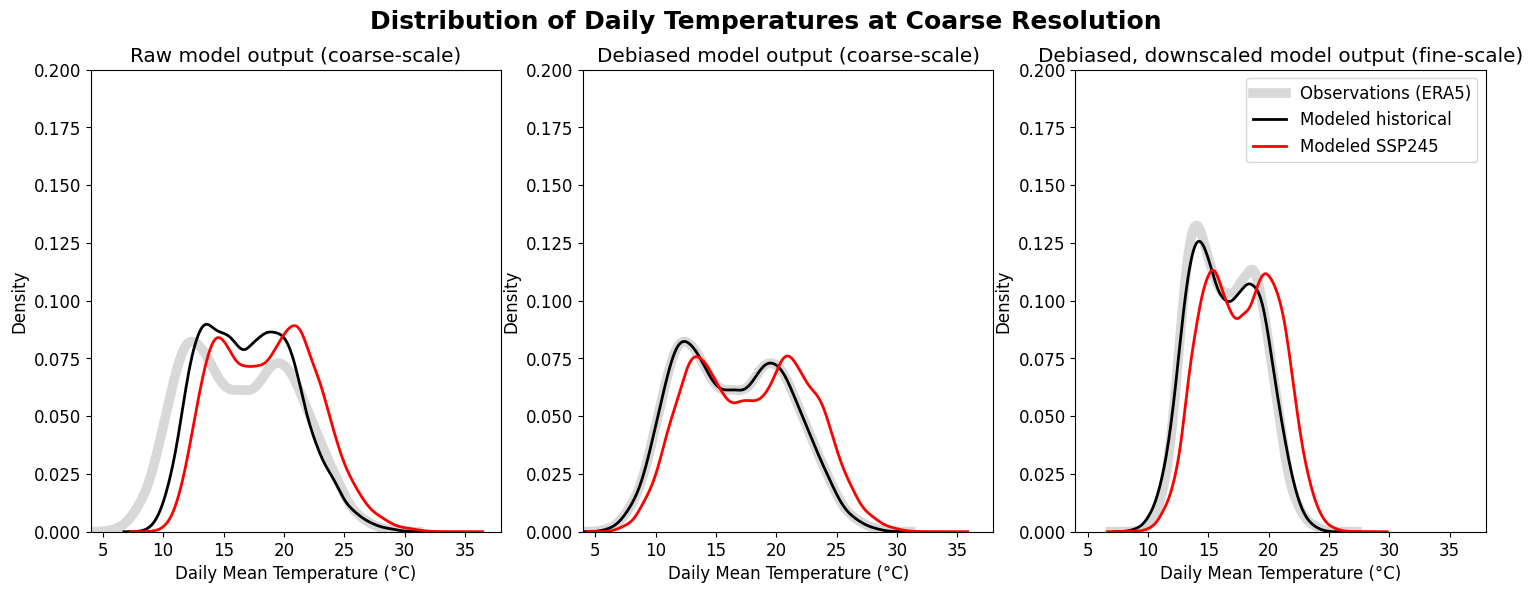

In [20]:
colors = ["black", "red"]
labels = ["Modeled historical", "Modeled SSP245"]
dataset_keys = ["model_hist", "model_scenario"]

plt.rcParams["font.size"] = 12


def format_subplot(res="coarse"):
    if res == "coarse":
        sns.kdeplot(
            dict_all_CT["obs_coarse"].as_numpy() - 273.15,
            label="Observations (ERA5)",
            color="gray",
            linewidth=7,
            alpha=0.3,
            linestyle="-",
        )
    elif res == "fine":
        sns.kdeplot(
            dict_all_CT["obs"] - 273.15,
            label="Observations (ERA5)",
            color="gray",
            linewidth=7,
            alpha=0.3,
            linestyle="-",
        )
    plt.ylim([0, 0.2])
    plt.xlim([4, 38])
    plt.xlabel("Daily Mean Temperature (°C)")


plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1)
format_subplot(res="coarse")
for i, key in enumerate(dataset_keys):
    sns.kdeplot(
        dict_all_CT[key] - 273.15,
        label=labels[i],
        color=colors[i],
        linewidth=2,
        linestyle="-",
    )
plt.title("Raw model output (coarse-scale)")


plt.subplot(1, 3, 2)
format_subplot(res="coarse")
for i, key in enumerate(dataset_keys):
    sns.kdeplot(
        dict_all_CT[key + "_debiased"] - 273.15,
        label=labels[i],
        color=colors[i],
        linewidth=2,
        linestyle="-",
    )
plt.title("Debiased model output (coarse-scale)")


plt.subplot(1, 3, 3)
format_subplot(res="fine")
for i, key in enumerate(dataset_keys):
    sns.kdeplot(
        dict_all_CT[key + "_debiased_downscaled"] - 273.15,
        label=labels[i],
        color=colors[i],
        linewidth=2,
        linestyle="-",
    )
plt.title("Debiased, downscaled model output (fine-scale)")

plt.suptitle(
    "Distribution of Daily Temperatures at Coarse Resolution",
    fontsize=18,
    fontweight="bold",
)

plt.legend(fontsize=12)